# Phase 16b — LoRA Only: Accuracy and Privacy Evaluation — UCI HAR (Walking)

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Overview

This notebook is the UCI HAR counterpart of the Dataset 1 LoRA-only evaluation.  
UCI HAR is restricted to **walking activities only** (labels 1–3: WALKING, WALKING\_UPSTAIRS, WALKING\_DOWNSTAIRS);  
static activities (SITTING, STANDING, LAYING) are discarded to align the activity distribution with WU Gait and WISDM.

It evaluates **LoRA alone** (without any CDML modulation) along two axes:

- **Continual Learning accuracy** — forgetting matrices, average accuracy, Task-1 retention
- **Privacy robustness** — three attacks in two attacker knowledge modes

### Attacker knowledge modes for LoRA

| Mode | What the attacker knows | Practical scenario |
|------|-------------------------|--------------------|
| **oracle (knows A,B)** | Has access to the correct task-specific LoRA adapter matrices | Insider / model-extraction scenario |
| **no-adapter (no A,B)** | Can query the base model only (frozen backbone, zero adapters) | Realistic black-box attacker |

### Attacks

| Attack | Type | Attacker modes |
|--------|------|----------------|
| **A — Identity Inference (IIA)** | Score-based MIA, black-box | no-adapter + oracle |
| **B — Feature Space Inference** | k-NN on embeddings, white-box | no-adapter + oracle |
| **C — Backdoor / Trojan** | Sinusoidal trigger, poisoning | no-adapter + oracle |

---


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [2]:
UCI_DATA_DIR    = '../Data/UCI HAR Dataset'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 30

EPOCHS   = 50    # 50 = fast iteration | 400 = paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.98

# ── Task splits (subject IDs, 1-indexed, ~7-8 subjects per task) ─────────────
TASK_SPLITS = {
    'Task 1': (1,   8),
    'Task 2': (9,  16),
    'Task 3': (17, 23),
    'Task 4': (24, 30),
}

# ── LoRA hyperparameters ──────────────────────────────────────────────────────
LORA_RANK  = 8     # rank r; try 4 / 8 / 16
LORA_ALPHA = 8     # scaling alpha; scaling factor = alpha/rank = 1.0

# ── Attack A — IIA ────────────────────────────────────────────────────────────
IIA_N_QUERIES  = 20

# ── Attack B — Feature Space Inference ───────────────────────────────────────
KNN_K = 5

# ── Attack C — Backdoor ───────────────────────────────────────────────────────
# Target must be in Task 4 (subjects 24-30 → 0-based indices 23-29)
BACKDOOR_TARGET_IDX   = 27   # subject 28 → 0-based index 27
BACKDOOR_POISON_FRAC  = 0.15
BACKDOOR_TRIGGER_AMP  = 0.5
BACKDOOR_TRIGGER_FREQ = 8
BACKDOOR_TRIGGER_CH   = 2    # acc_z

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')
print(f'  LoRA rank={LORA_RANK}, alpha={LORA_ALPHA}, scaling={LORA_ALPHA/LORA_RANK:.2f}')


Configuration set.
  LoRA rank=8, alpha=8, scaling=1.00


## 2. Data Loading

In [3]:
# UCI HAR: merge the mutually-exclusive train/test splits, filter to walking
# activities (labels 1-3), then re-split per subject so every subject appears
# in both train and test folds.
def _load_ucihar_split(data_dir, prefix):
    axes = ['total_acc_x', 'total_acc_y', 'total_acc_z',
            'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    X   = np.stack([
        np.loadtxt(f'{data_dir}/{prefix}/Inertial Signals/{a}_{prefix}.txt')
        for a in axes], axis=1).astype(np.float32)
    y   = np.loadtxt(f'{data_dir}/{prefix}/subject_{prefix}.txt', dtype=int)
    act = np.loadtxt(f'{data_dir}/{prefix}/y_{prefix}.txt',       dtype=int)
    return X, y, act

X_a, y_a, act_a = _load_ucihar_split(UCI_DATA_DIR, 'train')
X_b, y_b, act_b = _load_ucihar_split(UCI_DATA_DIR, 'test')

X_all   = np.concatenate([X_a, X_b], axis=0)
y_all   = np.concatenate([y_a, y_b], axis=0)
act_all = np.concatenate([act_a, act_b], axis=0)

# Walking-only filter (1=WALKING, 2=WALKING_UPSTAIRS, 3=WALKING_DOWNSTAIRS)
walk_mask = np.isin(act_all, [1, 2, 3])
X_all     = X_all[walk_mask]
y_all     = y_all[walk_mask]
print(f'UCI HAR walking-only: {walk_mask.sum()} / {len(walk_mask)} windows '
      f'({100*walk_mask.mean():.1f}%)')

# Per-subject stratified split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_SEED, stratify=y_all)

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                        task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')


Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test
Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model Definitions

### 3.1 Shared backbone (ConvBlock + GaitCNN)

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t

print('ConvBlock and evaluate() defined.')

ConvBlock and evaluate() defined.


### 3.2 LoRA Linear layer

In [5]:
class LoRALinear(nn.Module):
    """
    Linear layer with Low-Rank Adaptation (Hu et al. 2021).

    Forward:  y = W·x + b  +  (B_k · A_k)·x × (alpha / rank)

    W (base weight) is frozen after Task 1.
    A_k, B_k are task-specific adapters saved per task.

    Attacker modes
    ──────────────
    oracle    : load_lora(task_name) restores the correct (A_k, B_k)
    no-adapter: zero_lora() zeroes both adapters → only the frozen base W is used
    """
    def __init__(self, in_features, out_features, rank=LORA_RANK,
                 alpha=LORA_ALPHA, bias=True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.rank    = rank
        self.alpha   = alpha
        self.scaling = alpha / rank

        self.weight = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty(out_features, in_features),
                                     a=np.sqrt(5)))
        if bias:
            bound = 1 / np.sqrt(in_features) if in_features > 0 else 0
            self.bias = nn.Parameter(
                torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter('bias', None)

        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))

        self._lora_states: dict = {}   # {task_name: (A_cpu, B_cpu)}

    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base + lora

    # ── Adapter management ───────────────────────────────────────────────────
    def save_lora(self, task_name):
        self._lora_states[task_name] = (
            self.lora_A.data.cpu().clone(),
            self.lora_B.data.cpu().clone())

    def load_lora(self, task_name):
        A, B = self._lora_states[task_name]
        dev = self.lora_A.device
        self.lora_A.data.copy_(A.to(dev))
        self.lora_B.data.copy_(B.to(dev))

    def zero_lora(self):
        """Simulate an attacker who does not know A,B: zero both adapters."""
        nn.init.zeros_(self.lora_A)
        nn.init.zeros_(self.lora_B)

    def reset_lora(self):
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def freeze_base(self):
        self.weight.requires_grad_(False)
        if self.bias is not None:
            self.bias.requires_grad_(False)

    def lora_parameters(self):
        return [self.lora_A, self.lora_B]


print('LoRALinear defined.')

LoRALinear defined.


### 3.3 GaitCNN_LoRA — backbone with LoRA embedding and classifier

In [6]:
class GaitCNN_LoRA(nn.Module):
    """
    GaitCNN with LoRALinear for both the embedding and classifier layers.

    Task 1  → full model trained (backbone + LoRA adapters)
    Tasks 2+→ backbone frozen; only LoRA adapters (A_k, B_k) updated
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]

        self.embedding  = LoRALinear(flat, embed_dim,
                                     rank=lora_rank, alpha=lora_alpha)
        self.classifier = LoRALinear(embed_dim, n_classes,
                                     rank=lora_rank, alpha=lora_alpha)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))

    # ── LoRA adapter management ──────────────────────────────────────────────
    def save_lora(self, task_name):
        self.embedding.save_lora(task_name)
        self.classifier.save_lora(task_name)

    def load_lora(self, task_name):
        self.embedding.load_lora(task_name)
        self.classifier.load_lora(task_name)

    def zero_lora(self):
        """Attacker without A,B: zero both adapters — uses base model only."""
        self.embedding.zero_lora()
        self.classifier.zero_lora()

    def reset_lora(self):
        self.embedding.reset_lora()
        self.classifier.reset_lora()

    # ── Freezing ─────────────────────────────────────────────────────────────
    def freeze_base_weights(self):
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)
        self.embedding.freeze_base()
        self.classifier.freeze_base()
        print('  Backbone base weights frozen — only LoRA adapters will be trained.')

    def lora_parameters(self):
        return (self.embedding.lora_parameters() +
                self.classifier.lora_parameters())

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_parameter_count(self):
        return sum(p.numel() for p in self.parameters())


_m = GaitCNN_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
print(f'GaitCNN_LoRA total params:     {_m.total_parameter_count():,}')
print(f'GaitCNN_LoRA trainable T1:     {_m.trainable_parameter_count():,}')
_m.freeze_base_weights()
print(f'GaitCNN_LoRA trainable T2+:    {_m.trainable_parameter_count():,}  (LoRA only)')
del _m

GaitCNN_LoRA total params:     238,406
GaitCNN_LoRA trainable T1:     238,406
  Backbone base weights frozen — only LoRA adapters will be trained.
GaitCNN_LoRA trainable T2+:    11,184  (LoRA only)


## 4. Training

### 4.1 Shared epoch runner and evaluation utilities

In [7]:
def _run_epoch(model, loader, optimizer, criterion, device):
    model.train()
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        criterion(model(X_b), y_b).backward()
        optimizer.step()


@torch.no_grad()
def _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device):
    """Evaluate model on all tasks seen so far, loading the correct adapter per task."""
    model.eval()
    for j, t_name in enumerate(task_names[:step_idx + 1]):
        model.load_lora(t_name)
        loader = DataLoader(task_data[t_name]['test'], batch_size=256)
        acc_matrix[step_idx, j] = evaluate(model, loader, device)
    # Restore last task's adapter
    model.load_lora(task_names[step_idx])

print('Training utilities defined.')

Training utilities defined.


### 4.2 LoRA-only continual training loop

In [11]:
def train_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
               batch_size, label='LoRA', verbose_every=25):
    """
    Pure LoRA continual training (no CDML):
      Task 1  → train full model (CNN backbone + LoRA adapters)
      Tasks 2+ → freeze backbone, train only LoRA adapters (A_k, B_k)

    After each task: save adapter state.
    Eval:  load the per-task adapter for each past task.
    """
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        model.reset_lora()   # fresh adapters for every new task
        print(f'[{label}] Step {step_idx+1}: {task_name}')

        if step_idx == 0:
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
            n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'  Training full model ({n_params:,} params)')
        else:
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)
            n_params  = sum(p.numel() for p in model.lora_parameters())
            print(f'  Training LoRA only  ({n_params:,} params)')

        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                # FIX: Removed the erroneous `model.load_lora(task_name)` line
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx + 1)])
        print(f'  → {row}')

    return model, acc_matrix

print('train_lora() defined.')

train_lora() defined.


## 5. Train the LoRA Model

In [12]:
print('=' * 60)
print(f'Training LoRA model  (EPOCHS={EPOCHS})')
print('Set EPOCHS=400 for paper-accurate results.')
print('=' * 60)

# FIX: Replaced corrupted loop with the actual function call to train the model
model_lora, acc_lora = train_lora(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE
)

print()
print('── Final accuracy summary (after Task 4) ──')
print(f'  {"T1":>8} {"T2":>8} {"T3":>8} {"T4":>8}  {"Avg":>8}  T1-drop')
t1_init  = acc_lora[0, 0] * 100
t1_final = acc_lora[-1, 0] * 100
vals = [acc_lora[-1, j] * 100 for j in range(n_tasks)]
avg  = np.nanmean(acc_lora[-1, :]) * 100
drop = t1_init - t1_final
print('  ' + '  '.join([f'{v:>7.1f}%' for v in vals]) + f'  {avg:>7.1f}%  {drop:+.1f}pp')

Training LoRA model  (EPOCHS=50)
Set EPOCHS=400 for paper-accurate results.
[LoRA] Step 1: Task 1
  Training full model (238,406 params)
  Epoch   1/50  val=0.927
  Epoch  25/50  val=0.986
  Epoch  50/50  val=0.985
  → T1:89.8%
[LoRA] Step 2: Task 2
  Backbone base weights frozen — only LoRA adapters will be trained.
  Training LoRA only  (11,184 params)
  Epoch   1/50  val=0.507
  Epoch  25/50  val=0.949
  Epoch  50/50  val=0.957
  → T1:89.8%  T2:90.1%
[LoRA] Step 3: Task 3
  Backbone base weights frozen — only LoRA adapters will be trained.
  Training LoRA only  (11,184 params)
  Epoch   1/50  val=0.297
  Epoch  25/50  val=0.944
  Epoch  50/50  val=0.956
  → T1:89.8%  T2:90.1%  T3:89.1%
[LoRA] Step 4: Task 4
  Backbone base weights frozen — only LoRA adapters will be trained.
  Training LoRA only  (11,184 params)
  Epoch   1/50  val=0.327
  Epoch  25/50  val=0.961
  Epoch  50/50  val=0.976
  → T1:89.8%  T2:90.1%  T3:89.1%  T4:95.4%

── Final accuracy summary (after Task 4) ──
       

## 6. Accuracy Visualisation

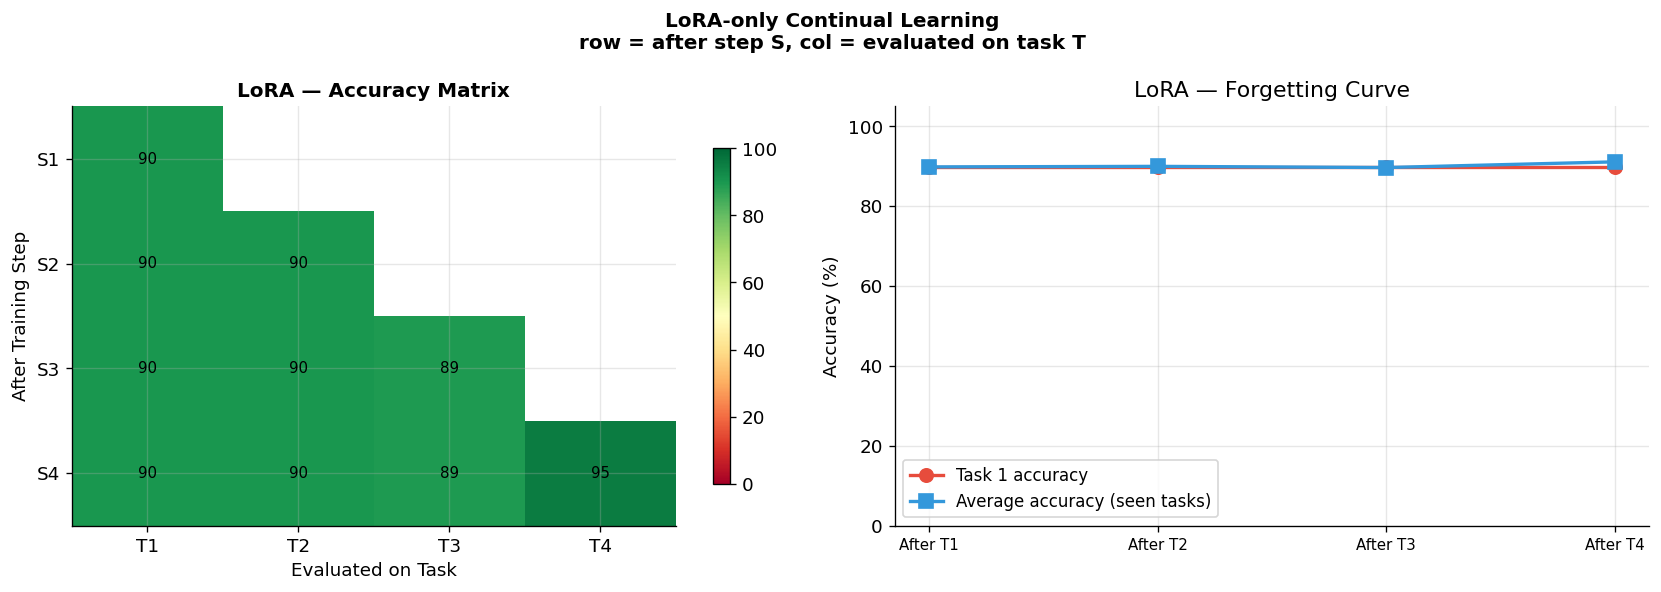

Parameter footprint:
  Total:                 238,406
  Frozen base:           227,222
  LoRA per task:          11,184  (44736 bytes/task)
  Compression ratio:  0.0492


In [13]:
# ── Accuracy matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
masked = np.ma.masked_invalid(acc_lora * 100)
im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(n_tasks)); ax.set_yticks(range(n_tasks))
ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
ax.set_yticklabels([f'S{i+1}' for i in range(n_tasks)])
ax.set_title('LoRA — Accuracy Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Evaluated on Task'); ax.set_ylabel('After Training Step')
for i in range(n_tasks):
    for j in range(n_tasks):
        if not np.isnan(acc_lora[i, j]):
            v = acc_lora[i, j] * 100
            ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                    fontsize=9, color='k' if v > 20 else 'w')

# ── Forgetting curve ─────────────────────────────────────────────────────────
ax2 = axes[1]
steps = list(range(1, n_tasks + 1))
t1_vals  = [acc_lora[s, 0] * 100 for s in range(n_tasks)]
avg_vals = [np.nanmean(acc_lora[s, :s+1]) * 100 for s in range(n_tasks)]
ax2.plot(steps, t1_vals,  'o-', color='#E74C3C', lw=2, ms=8, label='Task 1 accuracy')
ax2.plot(steps, avg_vals, 's-', color='#3498DB', lw=2, ms=8, label='Average accuracy (seen tasks)')
ax2.set_xticks(steps)
ax2.set_xticklabels([f'After T{s}' for s in steps], fontsize=9)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('LoRA — Forgetting Curve')
ax2.legend(fontsize=10)

fig.suptitle('LoRA-only Continual Learning\nrow = after step S, col = evaluated on task T',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_only_accuracy.png', bbox_inches='tight')
plt.show()

# ── Parameter footprint ───────────────────────────────────────────────────────
total_p = sum(p.numel() for p in model_lora.parameters())
lora_p  = sum(p.numel() for p in model_lora.lora_parameters())
base_p  = total_p - lora_p
print(f'Parameter footprint:')
print(f'  Total:              {total_p:>10,}')
print(f'  Frozen base:        {base_p:>10,}')
print(f'  LoRA per task:      {lora_p:>10,}  ({lora_p*4} bytes/task)')
print(f'  Compression ratio:  {lora_p/base_p:.4f}')

## 7. Attack A — Identity Inference Attack (IIA)

**Goal:** Was subject *s*'s gait data used to train the model for a given task?

**Score:** `score = −mean CE(model(xᵢ), s)` — lower loss → model "recognises" subject s.

**Attacker modes:**
- **oracle (knows A,B):** loads the correct task adapter before scoring
- **no-adapter:** zeroes A,B → uses the frozen base model only

In [14]:
@torch.no_grad()
def iia_score(model, X_windows, subj_idx, device):
    model.eval()
    X_windows = X_windows.to(device)
    y_true = torch.full((len(X_windows),), subj_idx, dtype=torch.long, device=device)
    losses = nn.CrossEntropyLoss(reduction='none')(
        model(X_windows), y_true).cpu().float().numpy()
    return float((-losses).mean())


def run_iia(model, task_data, task_names, device,
             lora_mode='oracle', n_queries=IIA_N_QUERIES):
    """
    lora_mode: 'oracle'     → load correct task adapter (attacker knows A,B)
               'no_adapter' → zero adapter (attacker only has base model)

    Returns {task_name: {auc, eer, fpr, tpr, m_scores, nm_scores}}
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):
        lo, hi    = TASK_SPLITS[task_name]
        task_subj = [label_to_idx[s] for s in range(lo, hi+1) if s in label_to_idx]
        test_ds   = task_data[task_name]['test']

        if lora_mode == 'oracle':
            model.load_lora(task_name)
        else:
            model.zero_lora()

        member_scores = []
        for subj_idx in task_subj:
            X_mem = torch.stack([test_ds[i][0] for i in range(len(test_ds))
                                  if test_ds[i][1].item() == subj_idx])
            if len(X_mem) == 0: continue
            member_scores.append(iia_score(model, X_mem[:n_queries], subj_idx, device))

        nonmember_scores = []
        for other_task in [t for t in task_names if t != task_name]:
            other_lo, other_hi = TASK_SPLITS[other_task]
            other_subjs = [label_to_idx[s] for s in range(other_lo, other_hi+1)
                           if s in label_to_idx]
            other_ds = task_data[other_task]['test']
            # Attacker always queries this task's adapter/mode
            if lora_mode == 'oracle':
                model.load_lora(task_name)
            else:
                model.zero_lora()
            for subj_idx in other_subjs:
                X_nm = torch.stack([other_ds[i][0] for i in range(len(other_ds))
                                     if other_ds[i][1].item() == subj_idx])
                if len(X_nm) == 0: continue
                nonmember_scores.append(
                    iia_score(model, X_nm[:n_queries], subj_idx, device))

        m_arr  = np.array(member_scores)
        nm_arr = np.array(nonmember_scores[:len(m_arr)])
        labels = np.concatenate([np.ones(len(m_arr)), np.zeros(len(nm_arr))])
        scores = np.concatenate([m_arr, nm_arr])
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc     = sk_auc(fpr, tpr)
        fnr = 1 - tpr
        eer = float(np.mean([fpr[np.nanargmin(np.abs(fpr-fnr))],
                              fnr[np.nanargmin(np.abs(fpr-fnr))]]))
        results[task_name] = {'auc': roc_auc, 'eer': eer,
                               'fpr': fpr, 'tpr': tpr,
                               'm_scores': m_arr, 'nm_scores': nm_arr}
    return results


print('Running IIA — oracle (knows A,B)...')
iia_oracle = run_iia(model_lora, task_data, task_names, DEVICE, lora_mode='oracle')
model_lora.load_lora(task_names[-1])  # restore

print('Running IIA — no-adapter (does not know A,B)...')
iia_no_ab  = run_iia(model_lora, task_data, task_names, DEVICE, lora_mode='no_adapter')
model_lora.load_lora(task_names[-1])

print()
print('── IIA AUC per task (50% = random / ideal) ──')
print(f'  {"Mode":<28} | ' + ' | '.join([f'{t:>8}' for t in task_names]) + ' | Avg')
print('  ' + '─' * 75)
for key, res in [('Oracle (knows A,B)', iia_oracle), ('No-adapter (no A,B)', iia_no_ab)]:
    aucs = [res[t]['auc']*100 for t in task_names]
    print(f'  {key:<28} | ' + ' | '.join([f'{a:>7.1f}%' for a in aucs])
          + f' | {np.mean(aucs):>5.1f}%')

Running IIA — oracle (knows A,B)...
Running IIA — no-adapter (does not know A,B)...

── IIA AUC per task (50% = random / ideal) ──
  Mode                         |   Task 1 |   Task 2 |   Task 3 |   Task 4 | Avg
  ───────────────────────────────────────────────────────────────────────────
  Oracle (knows A,B)           |    96.8% |    97.4% |    91.9% |    96.9% |  95.8%
  No-adapter (no A,B)          |    96.8% |     3.2% |     3.2% |     3.4% |  26.7%


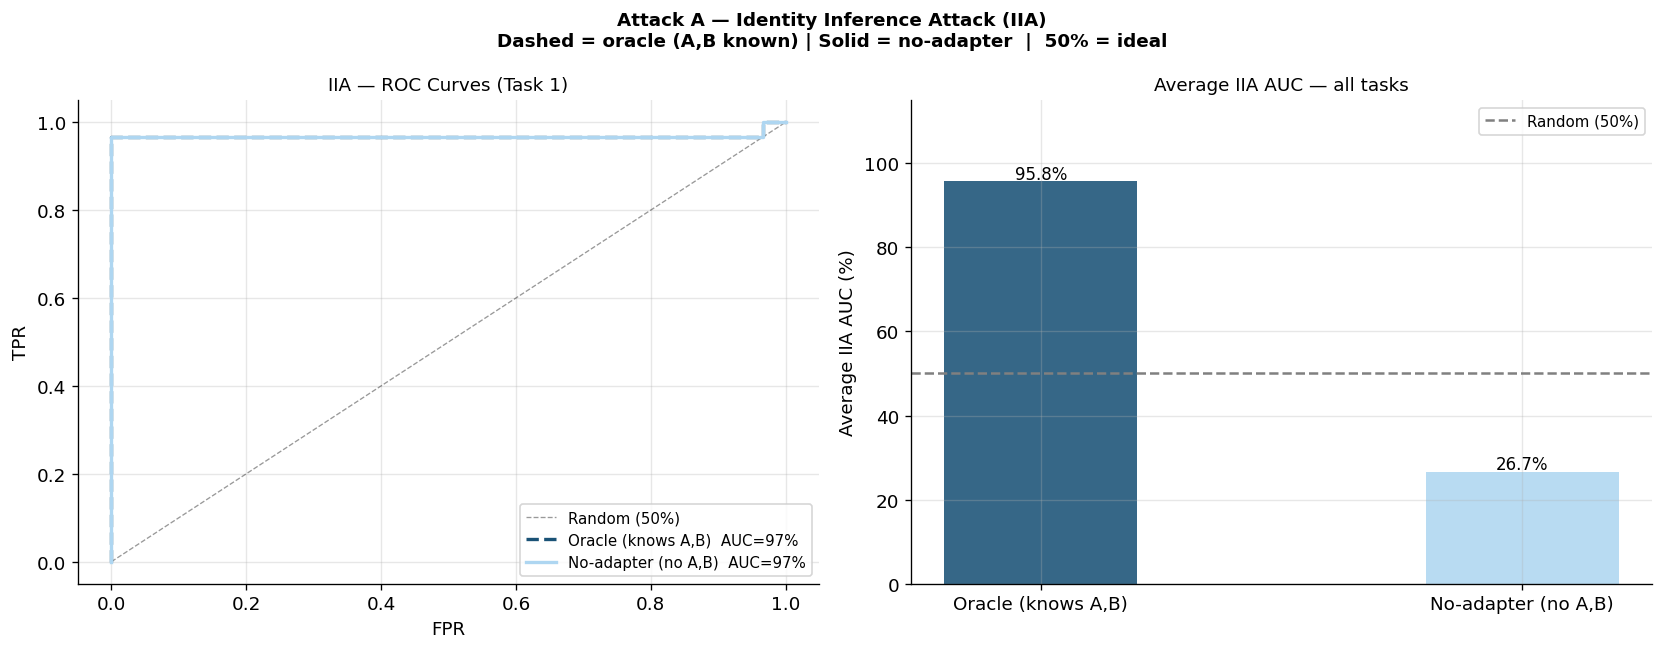

In [15]:
IIA_COLORS = {
    'Oracle (knows A,B)':   '#1A5276',
    'No-adapter (no A,B)':  '#AED6F1',
}

FOCUS_TASK = 'Task 1'
fig, axes  = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC curves
ax = axes[0]
ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4, label='Random (50%)')
for key, res, ls in [
    ('Oracle (knows A,B)',  iia_oracle, '--'),
    ('No-adapter (no A,B)', iia_no_ab,  '-'),
]:
    fpr, tpr = res[FOCUS_TASK]['fpr'], res[FOCUS_TASK]['tpr']
    ax.plot(fpr, tpr, color=IIA_COLORS[key], lw=2, ls=ls,
            label=f'{key}  AUC={res[FOCUS_TASK]["auc"]*100:.0f}%')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'IIA — ROC Curves ({FOCUS_TASK})', fontsize=11)
ax.legend(fontsize=9, loc='lower right')

# Average AUC bar chart
ax2 = axes[1]
modes    = ['Oracle (knows A,B)', 'No-adapter (no A,B)']
avg_aucs = [
    np.mean([iia_oracle[t]['auc']*100 for t in task_names]),
    np.mean([iia_no_ab[t]['auc']*100  for t in task_names]),
]
bars = ax2.bar(modes, avg_aucs,
               color=[IIA_COLORS[m] for m in modes], alpha=0.88, width=0.4)
ax2.axhline(50, color='gray', ls='--', lw=1.5, label='Random (50%)')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10)
ax2.set_ylabel('Average IIA AUC (%)')
ax2.set_title('Average IIA AUC — all tasks', fontsize=11)
ax2.set_ylim(0, 115); ax2.legend(fontsize=9)

plt.suptitle('Attack A — Identity Inference Attack (IIA)\n'
             'Dashed = oracle (A,B known) | Solid = no-adapter  |  50% = ideal',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_only_iia.png', bbox_inches='tight')
plt.show()

## 8. Attack B — Feature Space Inference

**Goal:** Can a k-NN classifier recover identity from the model's embedding space?

**Protocol:** Fit k-NN on training embeddings; evaluate top-1 identity accuracy on test embeddings.

**Attacker modes:**
- **oracle (knows A,B):** extracts embeddings with the correct adapter per task
- **no-adapter:** extracts embeddings with zeroed A,B → base model embeddings only

In [16]:
@torch.no_grad()
def extract_embeddings(model, dataset, device, lora_mode='oracle', task_name=None):
    """
    lora_mode: 'oracle'     → load correct task adapter
               'no_adapter' → zero the adapters
    """
    model.eval()
    if lora_mode == 'oracle' and task_name is not None:
        model.load_lora(task_name)
    else:
        model.zero_lora()

    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    all_h, all_y = [], []
    for X_b, y_b in loader:
        all_h.append(model.embed(X_b.to(device)).cpu().float().numpy())
        all_y.append(y_b.numpy())
    return np.concatenate(all_h), np.concatenate(all_y)


def run_feature_probe(model, task_data, task_names, device, lora_mode='oracle', k=KNN_K):
    # Build training embeddings
    tr_h_list, tr_y_list = [], []
    for t_name in task_names:
        h, y = extract_embeddings(model, task_data[t_name]['train'], device,
                                  lora_mode=lora_mode, task_name=t_name)
        tr_h_list.append(h); tr_y_list.append(y)
    tr_h = np.concatenate(tr_h_list); tr_y = np.concatenate(tr_y_list)

    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(tr_h, tr_y)

    results = {}
    for task_name in task_names:
        te_h, te_y = extract_embeddings(model, task_data[task_name]['test'], device,
                                        lora_mode=lora_mode, task_name=task_name)
        preds = knn.predict(te_h)
        results[task_name] = {
            'top1_acc':  (preds == te_y).mean(),
            'mean_conf': knn.predict_proba(te_h).max(axis=1).mean()
        }
    return results


chance = 1.0 / N_CLASSES_TOTAL  # 30 subjects total
print('Running Feature Space Inference — oracle (knows A,B)...')
probe_oracle = run_feature_probe(model_lora, task_data, task_names, DEVICE, lora_mode='oracle')
model_lora.load_lora(task_names[-1])

print('Running Feature Space Inference — no-adapter (does not know A,B)...')
probe_no_ab  = run_feature_probe(model_lora, task_data, task_names, DEVICE, lora_mode='no_adapter')
model_lora.load_lora(task_names[-1])

print(f'\n── Feature Probe top-1 accuracy (chance = {chance*100:.1f}%) ──')
for key, res in [('Oracle (knows A,B)', probe_oracle), ('No-adapter (no A,B)', probe_no_ab)]:
    avg = np.mean([res[t]['top1_acc'] for t in task_names]) * 100
    print(f'  {key:<30}: {avg:5.1f}%')

Running Feature Space Inference — oracle (knows A,B)...
Running Feature Space Inference — no-adapter (does not know A,B)...

── Feature Probe top-1 accuracy (chance = 3.3%) ──
  Oracle (knows A,B)            :  91.9%
  No-adapter (no A,B)           :  86.0%


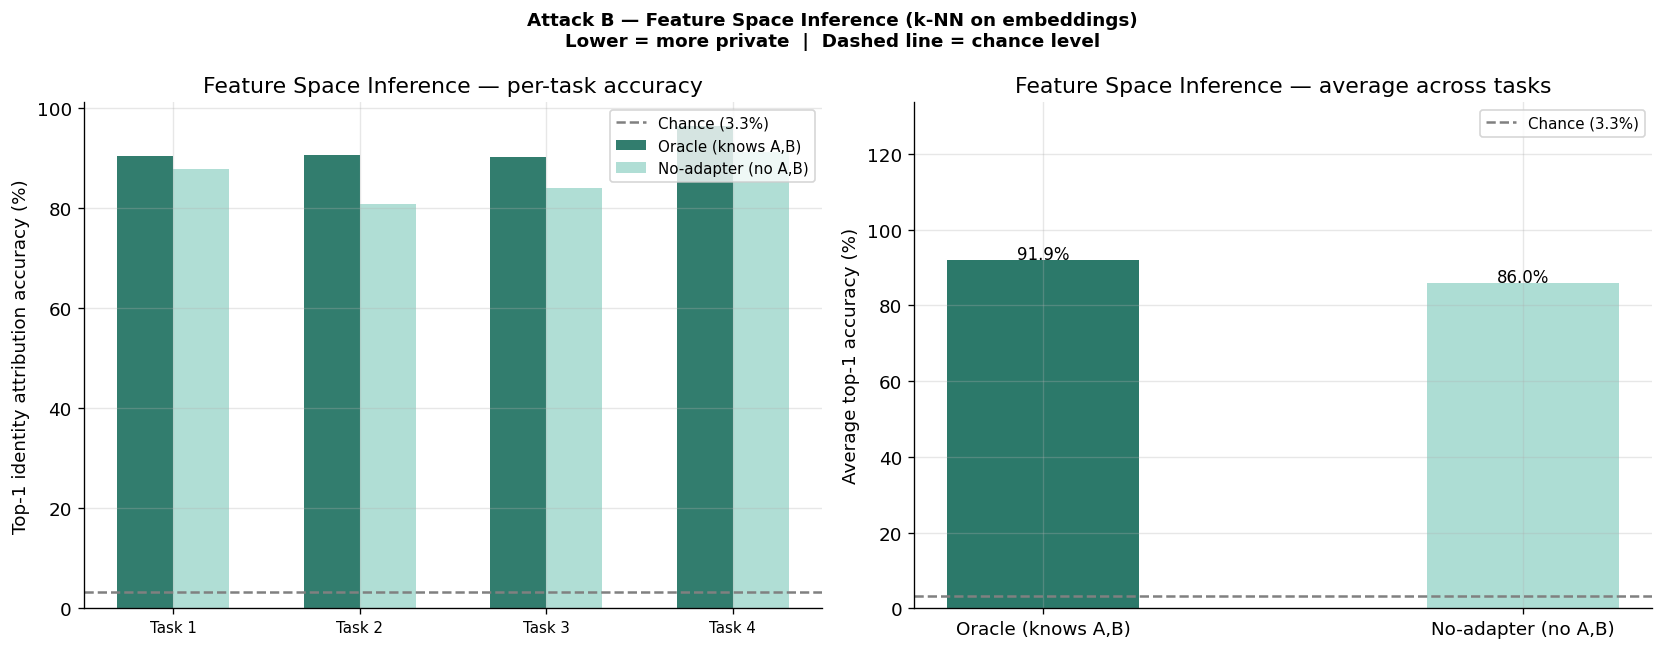

In [17]:
PROBE_COLORS = {
    'Oracle (knows A,B)':   '#0E6655',
    'No-adapter (no A,B)':  '#A2D9CE',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Per-task grouped bar chart
ax = axes[0]
x = np.arange(n_tasks); w = 0.3
for i, (key, res, color) in enumerate([
    ('Oracle (knows A,B)',  probe_oracle, PROBE_COLORS['Oracle (knows A,B)']),
    ('No-adapter (no A,B)', probe_no_ab,  PROBE_COLORS['No-adapter (no A,B)']),
]):
    vals   = [res[t]['top1_acc']*100 for t in task_names]
    offset = (i - 0.5) * w
    ax.bar(x + offset, vals, w, color=color, alpha=0.85, label=key)
ax.axhline(chance*100, color='gray', ls='--', lw=1.5, label=f'Chance ({chance*100:.1f}%)')
ax.set_xticks(x); ax.set_xticklabels(task_names, fontsize=9)
ax.set_ylabel('Top-1 identity attribution accuracy (%)')
ax.set_title('Feature Space Inference — per-task accuracy')
ax.legend(fontsize=9)

# Average accuracy
ax2 = axes[1]
modes    = ['Oracle (knows A,B)', 'No-adapter (no A,B)']
avg_accs = [
    np.mean([probe_oracle[t]['top1_acc']*100 for t in task_names]),
    np.mean([probe_no_ab[t]['top1_acc']*100  for t in task_names]),
]
bars = ax2.bar(modes, avg_accs,
               color=[PROBE_COLORS[m] for m in modes], alpha=0.88, width=0.4)
ax2.axhline(chance*100, color='gray', ls='--', lw=1.5, label=f'Chance ({chance*100:.1f}%)')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10)
ax2.set_ylabel('Average top-1 accuracy (%)')
ax2.set_title('Feature Space Inference — average across tasks')
ax2.set_ylim(0, max(avg_accs)*1.4 + 5); ax2.legend(fontsize=9)

plt.suptitle('Attack B — Feature Space Inference (k-NN on embeddings)\n'
             'Lower = more private  |  Dashed line = chance level',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_only_feature_probe.png', bbox_inches='tight')
plt.show()

## 9. Attack C — Backdoor / Trojan Attack

**Goal:** Inject a sinusoidal trigger during Task 3 training; test whether it forces
authentication as a target subject across all tasks.

**Design** (identical to Phase 11 for comparability):
- Target class = 90 (Task 4 subject)
- Trigger: sinusoidal on acc_z, amplitude = 0.5σ, freq = 8 Hz, 15% poison fraction

**LoRA hypothesis:** Tasks 2+ only update the small LoRA adapters (frozen backbone).
The backdoor pattern injected during Task 3 must be memorised entirely by the (A₃, B₃)
adapters — limiting how deeply the trigger can be embedded.

**Attacker modes:**
- **oracle (knows A,B):** loads the correct final-task adapter when testing ASR
- **no-adapter:** uses the base model only when testing ASR

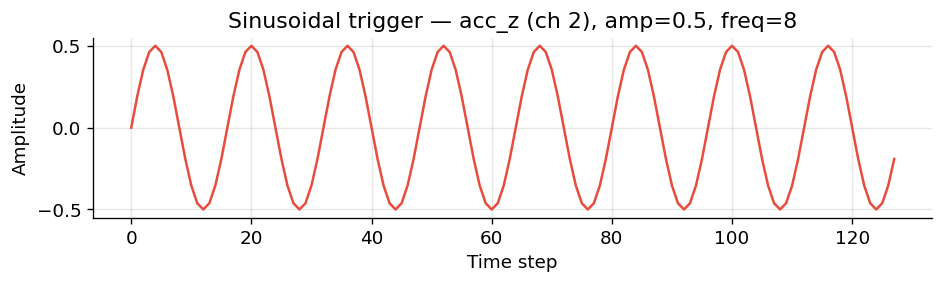

Building poisoned Task 3 dataset...
  Task 3: 5559 clean + 981 poisoned → target=90


In [18]:
TRIGGER = (BACKDOOR_TRIGGER_AMP * np.sin(
    2 * np.pi * BACKDOOR_TRIGGER_FREQ *
    np.arange(WINDOW_SIZE, dtype=np.float32) / WINDOW_SIZE)).astype(np.float32)


def inject_trigger(X, ch=BACKDOOR_TRIGGER_CH):
    if isinstance(X, torch.Tensor):
        X = X.clone()
        X[..., ch, :] += torch.tensor(TRIGGER, device=X.device)
    else:
        X = X.copy()
        X[..., ch, :] += TRIGGER
    return X


def build_poisoned_task3(task_data, poison_frac, target_idx):
    train_ds = task_data['Task 3']['train']
    n        = len(train_ds)
    n_poison = max(1, int(n * poison_frac))
    all_X    = torch.stack([train_ds[i][0] for i in range(n)])
    all_y    = torch.stack([train_ds[i][1] for i in range(n)])
    rng      = np.random.default_rng(RANDOM_SEED + 999)
    p_idx    = rng.choice(n, n_poison, replace=False)
    c_idx    = np.setdiff1d(np.arange(n), p_idx)
    X_p      = inject_trigger(all_X[p_idx])
    y_p      = torch.full((n_poison,), target_idx, dtype=torch.long)
    print(f'  Task 3: {len(c_idx)} clean + {n_poison} poisoned → target={target_idx}')
    return ConcatDataset([TensorDataset(all_X[c_idx], all_y[c_idx]),
                          TensorDataset(X_p, y_p)])


@torch.no_grad()
def measure_asr(model, task_data, task_names, device, target_idx,
                 final_task='Task 4', lora_mode='oracle'):
    """
    lora_mode: 'oracle'     → load final task adapter before measuring
               'no_adapter' → zero adapters
    """
    if lora_mode == 'oracle':
        model.load_lora(final_task)
    else:
        model.zero_lora()
    model.eval()
    total = success = 0
    for task_name in task_names:
        test_ds = task_data[task_name]['test']
        X_all   = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
        X_trig  = inject_trigger(X_all).to(device)
        preds   = model(X_trig).argmax(1)
        success += (preds == target_idx).sum().item()
        total   += len(X_trig)
    return success / total


@torch.no_grad()
def measure_clean_acc_lora(model, task_data, task_names, device):
    accs = []
    for task_name in task_names:
        model.load_lora(task_name)
        tl = DataLoader(task_data[task_name]['test'], batch_size=256)
        accs.append(evaluate(model, tl, device))
    return np.mean(accs)


# Trigger plot
t_axis = np.arange(WINDOW_SIZE)
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t_axis, TRIGGER, color='#E74C3C', lw=1.5)
ax.set_xlabel('Time step'); ax.set_ylabel('Amplitude')
ax.set_title(f'Sinusoidal trigger — acc_z (ch {BACKDOOR_TRIGGER_CH}), '
             f'amp={BACKDOOR_TRIGGER_AMP}, freq={BACKDOOR_TRIGGER_FREQ}')
plt.tight_layout()
plt.savefig('fig_lora_only_trigger.png', bbox_inches='tight')
plt.show()

print('Building poisoned Task 3 dataset...')
poisoned_t3  = build_poisoned_task3(task_data, BACKDOOR_POISON_FRAC, BACKDOOR_TARGET_IDX)
task_data_bd = {t: dict(task_data[t]) for t in task_names}
task_data_bd['Task 3']['train'] = poisoned_t3

In [19]:
print('Training backdoored LoRA model...')
model_lora_bd, _ = train_lora(
    task_data_bd, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    label='LoRA-BD')

print('\nMeasuring ASR and clean accuracy...')

asr_oracle    = measure_asr(model_lora_bd, task_data, task_names, DEVICE,
                             BACKDOOR_TARGET_IDX, lora_mode='oracle')
model_lora_bd.load_lora(task_names[-1])

asr_no_ab     = measure_asr(model_lora_bd, task_data, task_names, DEVICE,
                             BACKDOOR_TARGET_IDX, lora_mode='no_adapter')
model_lora_bd.load_lora(task_names[-1])

clean_bd      = measure_clean_acc_lora(model_lora_bd, task_data, task_names, DEVICE)
clean_orig    = np.nanmean(acc_lora[-1, :])

print(f'  ASR oracle    (knows A,B):  {asr_oracle*100:5.1f}%')
print(f'  ASR no-adapter (no A,B):    {asr_no_ab*100:5.1f}%')
print(f'  Clean acc (backdoored):     {clean_bd*100:5.1f}%')
print(f'  Clean acc (original):       {clean_orig*100:5.1f}%')
print(f'  Clean acc degradation:      {(clean_orig-clean_bd)*100:+.1f}pp')

Training backdoored LoRA model...
[LoRA-BD] Step 1: Task 1
  Training full model (238,406 params)
  Epoch   1/50  val=0.927
  Epoch  25/50  val=0.986
  Epoch  50/50  val=0.985
  → T1:89.8%
[LoRA-BD] Step 2: Task 2
  Backbone base weights frozen — only LoRA adapters will be trained.
  Training LoRA only  (11,184 params)
  Epoch   1/50  val=0.507
  Epoch  25/50  val=0.949
  Epoch  50/50  val=0.957
  → T1:89.8%  T2:90.1%
[LoRA-BD] Step 3: Task 3
  Backbone base weights frozen — only LoRA adapters will be trained.
  Training LoRA only  (11,184 params)
  Epoch   1/50  val=0.252
  Epoch  25/50  val=0.890
  Epoch  50/50  val=0.917
  → T1:89.8%  T2:90.1%  T3:81.6%
[LoRA-BD] Step 4: Task 4
  Backbone base weights frozen — only LoRA adapters will be trained.
  Training LoRA only  (11,184 params)
  Epoch   1/50  val=0.327
  Epoch  25/50  val=0.961
  Epoch  50/50  val=0.976
  → T1:89.8%  T2:90.1%  T3:81.6%  T4:95.4%

Measuring ASR and clean accuracy...
  ASR oracle    (knows A,B):    1.4%
  ASR no

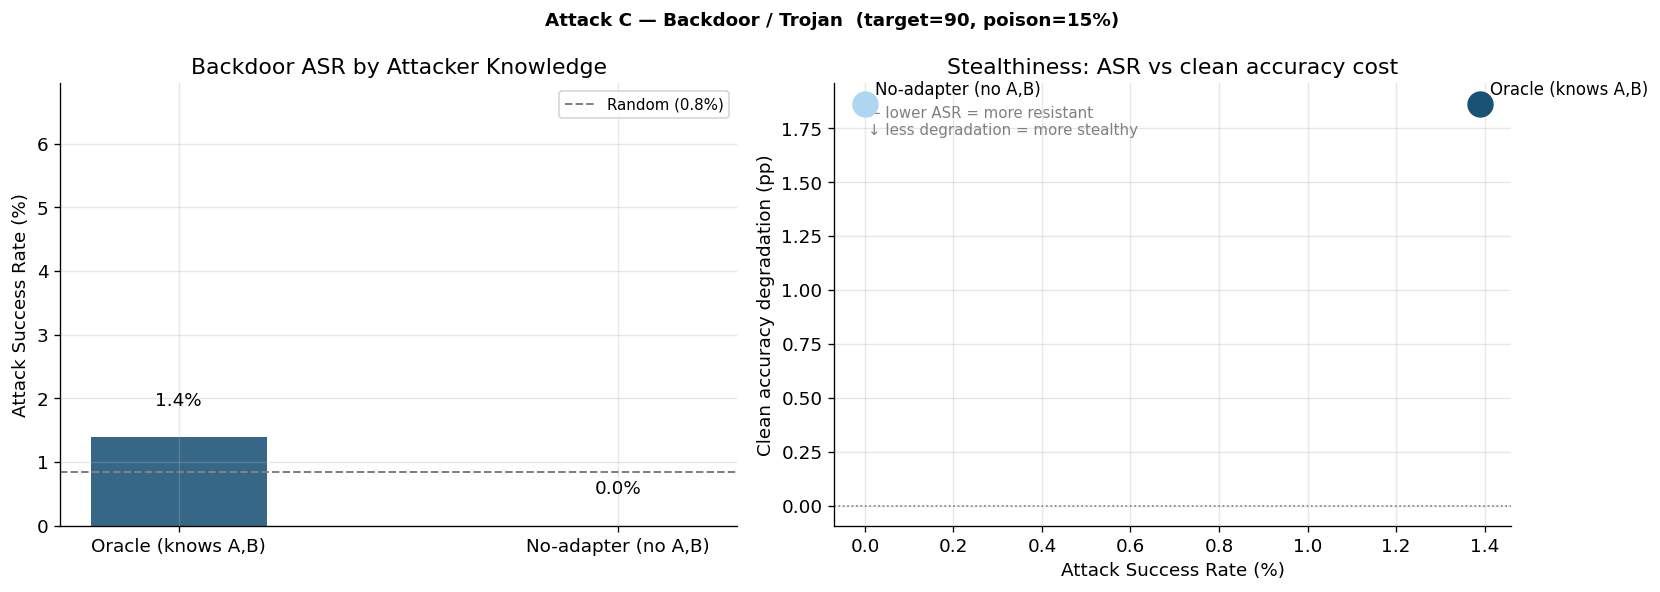

In [23]:
BD_COLORS = {
    'Oracle (knows A,B)':   '#1A5276',
    'No-adapter (no A,B)':  '#AED6F1',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ASR comparison
ax = axes[0]
modes    = ['Oracle (knows A,B)', 'No-adapter (no A,B)']
asr_vals = [asr_oracle*100, asr_no_ab*100]
bars = ax.bar(modes, asr_vals,
              color=[BD_COLORS[m] for m in modes], alpha=0.88, width=0.4)
ax.axhline(1/N_CLASSES_TOTAL*100, color='gray', ls='--', lw=1.2,
           label=f'Random ({1/N_CLASSES_TOTAL*100:.1f}%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
ax.set_ylabel('Attack Success Rate (%)')
ax.set_title('Backdoor ASR by Attacker Knowledge')
ax.set_ylim(0, max(asr_vals)*1.4 + 5)
ax.legend(fontsize=9)

# ASR vs clean accuracy degradation scatter
ax2 = axes[1]
clean_drop = (clean_orig - clean_bd) * 100
for mode, asr_val, color in [
    ('Oracle (knows A,B)',  asr_oracle*100, BD_COLORS['Oracle (knows A,B)']),
    ('No-adapter (no A,B)', asr_no_ab*100,  BD_COLORS['No-adapter (no A,B)']),
]:
    ax2.scatter(asr_val, clean_drop, color=color, s=220, zorder=5)
    ax2.annotate(mode, (asr_val, clean_drop), textcoords='offset points',
                  xytext=(6, 5), fontsize=10)
ax2.set_xlabel('Attack Success Rate (%)')
ax2.set_ylabel('Clean accuracy degradation (pp)')
ax2.set_title('Stealthiness: ASR vs clean accuracy cost')
ax2.axhline(0, color='gray', ls=':', lw=1)
ax2.text(0.05, 0.95,
         '← lower ASR = more resistant\n↓ less degradation = more stealthy',
         transform=ax2.transAxes, fontsize=9, color='gray', va='top')

plt.suptitle(f'Attack C — Backdoor / Trojan  '
             f'(target={BACKDOOR_TARGET_IDX}, poison={BACKDOOR_POISON_FRAC*100:.0f}%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_only_backdoor.png', bbox_inches='tight')
plt.show()

## 10. Final Summary — Accuracy & Privacy Trade-off

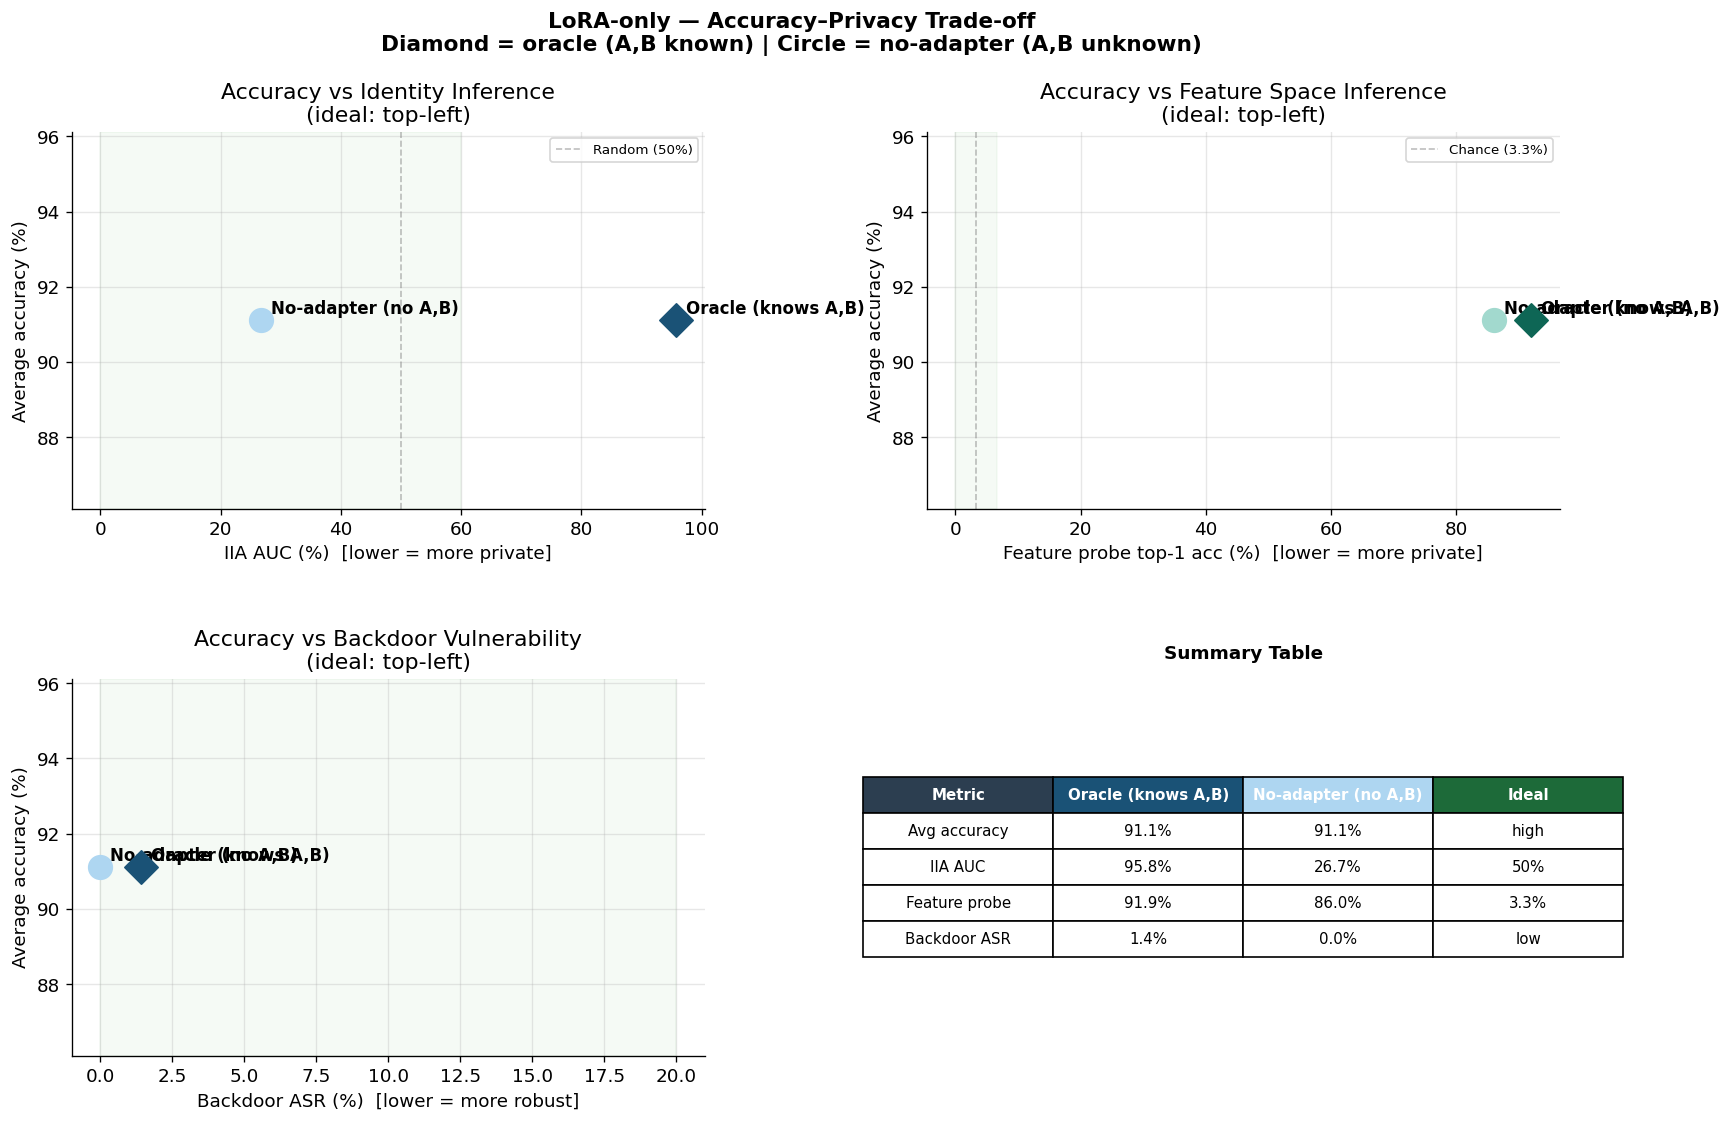

In [24]:
# ── Accuracy–Privacy scatter ──────────────────────────────────────────────────
iia_auc_oracle  = np.mean([iia_oracle[t]['auc']*100  for t in task_names])
iia_auc_no_ab   = np.mean([iia_no_ab[t]['auc']*100   for t in task_names])
probe_oracle_avg= np.mean([probe_oracle[t]['top1_acc']*100 for t in task_names])
probe_no_ab_avg = np.mean([probe_no_ab[t]['top1_acc']*100  for t in task_names])
avg_acc         = np.nanmean(acc_lora[-1, :]) * 100

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Accuracy vs IIA AUC
ax1 = fig.add_subplot(gs[0, 0])
for mode, auc_val, color, marker in [
    ('Oracle (knows A,B)',  iia_auc_oracle, '#1A5276', 'D'),
    ('No-adapter (no A,B)', iia_auc_no_ab,  '#AED6F1', 'o'),
]:
    ax1.scatter(auc_val, avg_acc, color=color, s=200, marker=marker, zorder=5)
    ax1.annotate(mode, (auc_val, avg_acc), textcoords='offset points',
                  xytext=(6, 4), fontsize=10, fontweight='bold')
ax1.axvline(50, color='gray', ls='--', lw=1, alpha=0.5, label='Random (50%)')
ax1.set_xlabel('IIA AUC (%)  [lower = more private]')
ax1.set_ylabel('Average accuracy (%)')
ax1.set_title('Accuracy vs Identity Inference\n(ideal: top-left)')
ax1.legend(fontsize=8)
ax1.axvspan(0, 60, alpha=0.04, color='green')

# Panel 2: Accuracy vs Feature Probe
ax2 = fig.add_subplot(gs[0, 1])
for mode, probe_val, color, marker in [
    ('Oracle (knows A,B)',  probe_oracle_avg, '#0E6655', 'D'),
    ('No-adapter (no A,B)', probe_no_ab_avg,  '#A2D9CE', 'o'),
]:
    ax2.scatter(probe_val, avg_acc, color=color, s=200, marker=marker, zorder=5)
    ax2.annotate(mode, (probe_val, avg_acc), textcoords='offset points',
                  xytext=(6, 4), fontsize=10, fontweight='bold')
ax2.axvline(chance*100, color='gray', ls='--', lw=1, alpha=0.5,
             label=f'Chance ({chance*100:.1f}%)')
ax2.set_xlabel('Feature probe top-1 acc (%)  [lower = more private]')
ax2.set_ylabel('Average accuracy (%)')
ax2.set_title('Accuracy vs Feature Space Inference\n(ideal: top-left)')
ax2.legend(fontsize=8)
ax2.axvspan(0, chance*100*2, alpha=0.04, color='green')

# Panel 3: Accuracy vs Backdoor ASR
ax3 = fig.add_subplot(gs[1, 0])
for mode, asr_val, color, marker in [
    ('Oracle (knows A,B)',  asr_oracle*100, '#1A5276', 'D'),
    ('No-adapter (no A,B)', asr_no_ab*100,  '#AED6F1', 'o'),
]:
    ax3.scatter(asr_val, avg_acc, color=color, s=200, marker=marker, zorder=5)
    ax3.annotate(mode, (asr_val, avg_acc), textcoords='offset points',
                  xytext=(6, 4), fontsize=10, fontweight='bold')
ax3.set_xlabel('Backdoor ASR (%)  [lower = more robust]')
ax3.set_ylabel('Average accuracy (%)')
ax3.set_title('Accuracy vs Backdoor Vulnerability\n(ideal: top-left)')
ax3.axvspan(0, 20, alpha=0.04, color='green')

# Panel 4: Summary table
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
table_data = [
    ['Metric', 'Oracle (knows A,B)', 'No-adapter (no A,B)', 'Ideal'],
    ['Avg accuracy', f'{avg_acc:.1f}%', f'{avg_acc:.1f}%', 'high'],
    ['IIA AUC',      f'{iia_auc_oracle:.1f}%', f'{iia_auc_no_ab:.1f}%', '50%'],
    ['Feature probe', f'{probe_oracle_avg:.1f}%', f'{probe_no_ab_avg:.1f}%', f'{chance*100:.1f}%'],
    ['Backdoor ASR', f'{asr_oracle*100:.1f}%',   f'{asr_no_ab*100:.1f}%',   'low'],
]
col_colors = [['#EAECEE']*4]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center',
                colColours=['#2C3E50', '#1A5276', '#AED6F1', '#1D6A39'])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(color='white', fontweight='bold')
ax4.set_title('Summary Table', fontsize=11, fontweight='bold', pad=12)

fig.suptitle('LoRA-only — Accuracy–Privacy Trade-off\n'
             'Diamond = oracle (A,B known) | Circle = no-adapter (A,B unknown)',
             fontsize=13, fontweight='bold')
plt.savefig('fig_lora_only_tradeoff.png', bbox_inches='tight')
plt.show()

In [25]:
print('=' * 72)
print('COMPLETE SUMMARY — LoRA Only (no CDML)')
print('=' * 72)

# Accuracy
print(f'\n{"━"*72}')
print('CONTINUAL LEARNING ACCURACY (after Task 4)')
print(f'  {"T1":>8} {"T2":>8} {"T3":>8} {"T4":>8}  {"Avg":>8}  T1-drop')
t1_i = acc_lora[0, 0]*100
t1_f = acc_lora[-1, 0]*100
vs   = [acc_lora[-1, j]*100 for j in range(n_tasks)]
print('  ' + ''.join([f' {v:>7.1f}%' for v in vs])
      + f'  {np.nanmean(acc_lora[-1,:])*100:>7.1f}%  {t1_i-t1_f:+.1f}pp')

# Attack A
print(f'\n{"━"*72}')
print('ATTACK A — IIA AUC (50% = random = ideal)')
for key, res in [('Oracle (knows A,B)', iia_oracle), ('No-adapter (no A,B)', iia_no_ab)]:
    aucs = [res[t]['auc']*100 for t in task_names]
    avg  = np.mean(aucs)
    prot = '✓ YES' if avg < 60 else ('~ PARTIAL' if avg < 70 else '✗ NO')
    print(f'  {key:<28}  avg={avg:5.1f}%  {prot}')
    print('   per task: ' + '  '.join([f'T{i+1}:{a:.1f}%' for i,a in enumerate(aucs)]))

# Attack B
print(f'\n{"━"*72}')
print(f'ATTACK B — Feature Probe top-1 (chance={chance*100:.1f}%)')
for key, res in [('Oracle (knows A,B)', probe_oracle), ('No-adapter (no A,B)', probe_no_ab)]:
    accs = [res[t]['top1_acc']*100 for t in task_names]
    avg  = np.mean(accs)
    prot = '✓ YES' if avg < chance*100*3 else '✗ NO'
    print(f'  {key:<28}  avg={avg:5.1f}%  {prot}')
    print('   per task: ' + '  '.join([f'T{i+1}:{a:.1f}%' for i,a in enumerate(accs)]))

# Attack C
print(f'\n{"━"*72}')
print('ATTACK C — Backdoor')
clean_drop = (clean_orig - clean_bd) * 100
for key, asr_val in [('Oracle (knows A,B)', asr_oracle), ('No-adapter (no A,B)', asr_no_ab)]:
    stealthy = '✓ YES' if clean_drop < 3.0 else '✗ NO'
    print(f'  {key:<28}  ASR={asr_val*100:5.1f}%  clean_drop={clean_drop:+.1f}pp  stealthy={stealthy}')

print(f'\n{"━"*72}')
print('KEY INSIGHT: Oracle vs No-adapter gap')
print(f'  IIA AUC gap:      {iia_auc_oracle - iia_auc_no_ab:+.1f}pp  '
      f'(oracle is {"more" if iia_auc_oracle > iia_auc_no_ab else "less"} vulnerable)')
print(f'  Feature probe gap:{probe_oracle_avg - probe_no_ab_avg:+.1f}pp')
print(f'  ASR gap:          {(asr_oracle - asr_no_ab)*100:+.1f}pp')
print()
print('Note: a large oracle vs no-adapter gap means that the LoRA adapters')
print('  carry significant task-specific information. Without CDML, an attacker')
print('  who obtains the adapter matrices has substantially higher attack power.')

COMPLETE SUMMARY — LoRA Only (no CDML)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONTINUAL LEARNING ACCURACY (after Task 4)
        T1       T2       T3       T4       Avg  T1-drop
      89.8%    90.1%    89.1%    95.4%     91.1%  +0.0pp

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ATTACK A — IIA AUC (50% = random = ideal)
  Oracle (knows A,B)            avg= 95.8%  ✗ NO
   per task: T1:96.8%  T2:97.4%  T3:91.9%  T4:96.9%
  No-adapter (no A,B)           avg= 26.7%  ✓ YES
   per task: T1:96.8%  T2:3.2%  T3:3.2%  T4:3.4%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ATTACK B — Feature Probe top-1 (chance=3.3%)
  Oracle (knows A,B)            avg= 91.9%  ✗ NO
   per task: T1:90.4%  T2:90.6%  T3:90.2%  T4:96.4%
  No-adapter (no A,B)           avg= 86.0%  ✗ NO
   per task: T1:87.9%  T2:80.9%  T3:84.0%  T4:91.2%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ATTACK C — Backdoor

Note: this is the UCI HAR (walking-only) counterpart of the Dataset 1 LoRA-only notebook.

The data pipeline merges the original train/test splits (which separate subjects entirely)
and re-splits per subject, retaining only the three walking activities (labels 1-3).

Expected behaviour:
* LoRA alone provides no CDML-based privacy protection — the oracle attacker who knows (A, B)
  has substantially higher IIA AUC and feature probe accuracy than the no-adapter attacker.
* The no-adapter attacker can still exploit Task 1 weights (W is trained on Task 1 subjects),
  but is blind to the other tasks' adapter-encoded information.
* Accuracy and forgetting profiles should mirror the Dataset 1 LoRA-only results qualitatively,
  though absolute numbers differ due to the smaller subject pool (30 vs 118).
